# SMS Spam Detection pomocu ANN modela

Cilj projekta je klasifikovati SMS poruke kao:

- spam
- ham

Koristimo UCI SMS Spam Collection dataset.

Pipeline projekta je sljedeci:

SMS tekst -> Tokenizer -> sekvence brojeva -> padding -> ANN model -> spam/ham

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

np.random.seed(42)
tf.random.set_seed(42)

In [195]:
!wget -q https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip
!unzip -q -o sms+spam+collection.zip

In [196]:
!ls

readme		   sms+spam+collection.zip    sms+spam+collection.zip.3
sample_data	   sms+spam+collection.zip.1  sms+spam+collection.zip.4
SMSSpamCollection  sms+spam+collection.zip.2


## Ucitavanje dataseta

Dataset se nalazi u fajlu `SMSSpamCollection`.

Svaki red ima dva dijela:

- labelu: `ham` ili `spam`
- tekst SMS poruke

Posto fajl nema nazive kolona, rucno dodajemo kolone `label` i `message`.

In [197]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [198]:
df.shape

(5572, 2)

In [199]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


## Brzinska analiza dataset-a

Dataset je nebalansiran, jer ima vise normalnih ham poruka nego spam poruka. Zato accuracy nije jedina dovoljna metrika, nego cemo kasnije da gledamo i `precision`, `recall` i `F1-score`, te cemo analizirati te rezultate.

In [200]:
df.isnull().sum()

,0
label,0
message,0


Nemamo nedostajucih vrijednosti unutar dataset-a.

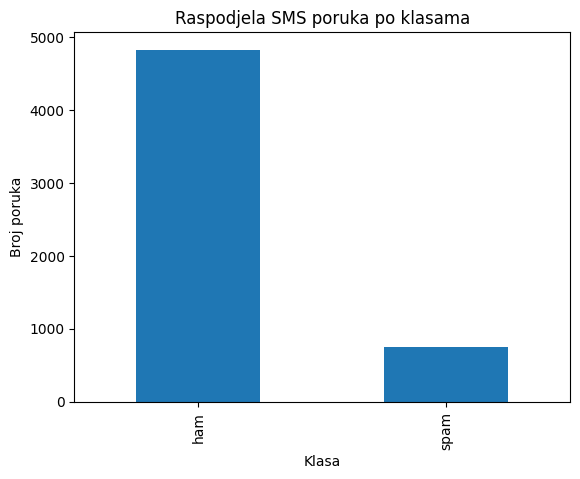

In [201]:
df["label"].value_counts().plot(kind="bar")

plt.title("Raspodjela SMS poruka po klasama")
plt.xlabel("Klasa")
plt.ylabel("Broj poruka")
plt.show()

## Pretvaranje labela u brojeve

Model ne može direktno raditi sa tekstualnim labelama `ham` i `spam`.

Zato ih pretvaramo u brojeve:

- `ham` -> 0
- `spam` -> 1

Posto zelimo predvidjeti da li je poruka spam, spam oznacavamo kao pozitivnu klasu `1`.

In [202]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


Sada odjavamo ulaz i izlaz:

`X` = tekstovi SMS poruka

`y` = klase 0/1

In [203]:
X = df["message"].values
y = df["label_num"].values

In [204]:
print("Primjer poruke:")
print(X[0])

print("\nLabela:")
print(y[0])

Primjer poruke:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Labela:
0


## Podjela na trening i test skup

Podatke dijelimo na:

- trening skup: koristi se za ucenje modela
- test skup: koristi se za konacnu provjeru modela

Koristimo 80% podataka za trening i 20% za testiranje.

Parametar `stratify=y` cuva priblizno isti omjer `ham` i `spam` poruka u trening i test skupu. Bez stratify recimo, moze se desiti da test skup dobije premalo spam poruka, pa evaluacija ne bude realna, pa model ima visok accuracy samo zato sto dobro pogadja ham.

Takodjer, moguce je da model ne nauci dovoljno dobro spam da prepoznaje, jer u treningu nije vidio dovoljno spam primjera.

In [205]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [206]:
print("Broj trening poruka:", len(X_train))
print("Broj test poruka:", len(X_test))

Broj trening poruka: 4457
Broj test poruka: 1115


In [207]:
print("Omjer klasa u cijelom datasetu:")
print(pd.Series(y).value_counts(normalize=True))

print("\nOmjer klasa u trening skupu:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nOmjer klasa u test skupu:")
print(pd.Series(y_test).value_counts(normalize=True))

Omjer klasa u cijelom datasetu:
0    0.865937
1    0.134063
Name: proportion, dtype: float64

Omjer klasa u trening skupu:
0    0.865829
1    0.134171
Name: proportion, dtype: float64

Omjer klasa u test skupu:
0    0.866368
1    0.133632
Name: proportion, dtype: float64


Dakle, koristenjem stratify podijelu dobija se trening i test skup koji imaju priblizno isti omjer `spam` i `ham` poruka kao i originalni dataset.

## Tokenizacija teksta

Neuronska mreza ne moze direktno raditi sa tekstom.

Zato koristimo `Tokenizer`, koji svakoj rijeci dodjeljuje jedan broj.

Na primjer:

- "free" -> 15
- "call" -> 31
- "now" -> 57

Nakon tokenizacije, svaka SMS poruka postaje sekvenca brojeva.

Tokenizer ucimo samo na trening podacima, da ne bi model unaprijed vidio informacije iz test skupa.

In [208]:
VOCAB_SIZE = 10000
OOV_TOKEN = "<OOV>"

VOCAB_SIZE = maksimalan broj rijeci koje tokenizer cuva

OOV_TOKEN = oznaka za rijeci koje nisu vidjene u trening skupu

In [209]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

In [210]:
tokenizer.fit_on_texts(X_train)

In [211]:
word_index = tokenizer.word_index

print("Broj rijeci u rijecniku:", len(word_index))
print("Prvih 20 rijeci:")
print(list(word_index.items())[:20])

Broj rijeci u rijecniku: 7934
Prvih 20 rijeci:
[('<OOV>', 1), ('i', 2), ('to', 3), ('you', 4), ('a', 5), ('the', 6), ('u', 7), ('and', 8), ('in', 9), ('is', 10), ('my', 11), ('me', 12), ('for', 13), ('your', 14), ('it', 15), ('call', 16), ('of', 17), ('have', 18), ('on', 19), ('2', 20)]


## Pretvaranje teksta u sekvence brojeva

Nakon sto je Tokenizer napravio rijecnik, svaku SMS poruku pretvaramo u listu brojeva pomocu `texts_to_sequences`.

Na primjer:

"call me now"

moze postati:

[31, 18, 57]

In [212]:
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

In [213]:
print("Originalna poruka:")
print(X_train[0])

print("\nSekvenca brojeva:")
print(train_sequences[0])

Originalna poruka:
He will, you guys close?

Sekvenca brojeva:
[72, 33, 4, 339, 670]


## Padding

Sljedeci problem koji treba da se rjesi je taj da su neke SMS poruke kratke dok su neke SMS poruke duge. Neuronska mreza ocekuje da je svaki ulaz iste duzine i iz tog razloga cemo da koristimo padding.

Razlog za padding je zato sto neuronska mreza obradjuje podatke u matricama/tesnorima. Da bi se vise poruka moglo obraditi zajedno u batch-u, svaka poruka mora imati isti broj tokena.

Ako je poruka kraca od zadane duzine, dodaju se nule. Ako je poruka duza od zadane duzine, skracuje se.

In [214]:
MAX_LENGTH = 50
PADDING_TYPE = "post"
TRUNC_TYPE = "post"

MAX_LENGTH = svaka poruka ce imati 50 brojeva

PADDING_TYPE = "post" znaci da se nule dodaju na kraj

TRUNC_TYPE = "post" znaci da se preduge poruke skracuju sa kraja

In [215]:
X_train_padded = pad_sequences(
    train_sequences,
    maxlen=MAX_LENGTH,
    padding=PADDING_TYPE,
    truncating=TRUNC_TYPE
)

X_test_padded = pad_sequences(
    test_sequences,
    maxlen=MAX_LENGTH,
    padding=PADDING_TYPE,
    truncating=TRUNC_TYPE
)

In [216]:
print("Oblik trening podataka:", X_train_padded.shape)
print("Oblik test podataka:", X_test_padded.shape)

Oblik trening podataka: (4457, 50)
Oblik test podataka: (1115, 50)


Dakle imamo sada 4457 trening poruka , 1115 test poruka i svaka poruka ima 50 brojeva.

In [217]:
print("Originalna sekvenca:")
print(train_sequences[0])

print("\nSekvenca nakon paddinga:")
print(X_train_padded[0])

Originalna sekvenca:
[72, 33, 4, 339, 670]

Sekvenca nakon paddinga:
[ 72  33   4 339 670   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


## Kreiranje ANN modela

Nakon tokenizacije i paddinga, tekstualne poruke su pretvorene u numericke sekvence.

Sada pravimo ANN model koji se sastoji od:

1. `Embedding` sloja
2. `GlobalAveragePooling1D` sloja
3. `Dense` sloja
4. `Dropout` sloja
5. izlaznog `Dense` sloja sa sigmoid aktivacijom

Posto imamo binarnu klasifikaciju, izlaz je jedna vrijednost izmedju 0 i 1.

Vrijednost blizu 0 znaci `ham`, a vrijednost blizu 1 znaci `spam`.

In [218]:
EMBEDDING_DIM = 16

Ovo znaci da ce svaka rijec biti predstavljena vektorom od 16 brojeva. Na primjer rijec "free" nece biti samo jedan broj nego vektor `[0.12, -0.44, 0.31, ..., 0.88]`.

Dense sloj ce da ima 24 neurona.

Koristit cemo `ReLU` aktivaciju u `Dense` sloju zato sto omogucava modelu da uci nelinearne odnose izmedju rijeci i klase poruke. `ReLU` propusta pozitivne vrijednosti, a negativne postavlja na nulu, cime model lakse uci bitne karakteristike koji razlikuju spam od ham poruka.

U sustini radi u principu ReLU(x) = max(0, x).

Za dropout cemo uzeti da se 30% neurona iz prethodnog sloja nasumicno "ugasi" prilikom treniranja.

To se radi da model ne bi previse zavisio od istih neurona i da ne bi ucio napamet.

Imamo jedan neuron u izlaznom sloju posto imamo binarnu klasifikaciju, dovoljan nam je jedan izlazni neuron koji daje broj izmedju 0 i 1.

In [219]:
model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    GlobalAveragePooling1D(),

    Dense(24, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

## Analiza slojeva


### Embedding

`Embedding` sloj pretvara svaku rijec, odnosno svaki njen token, u vektor brojeva koji neuronska mreza moze obraditi. Tokenizacija ce da pretvori rijeci prvo u ID-eve, na primjer `"free ticket now"` u `[15, 82, 10]`, ali ti brojevi sami po sebi ne nose nikakvo znacenje. Zato cemo embedding slojem svakom tokenu dodijeliti vektor, odnosno niz brojeva koji se tokom treninga prilagodjavaju.

Ako se rijec `free` cesto pojavljuje u spam porukama, njen se embedding postepeno podesava tako da modelu pomaze da je prepozna kao spam signal.

### GlobalAveragePooling1D

Nakon `Embedding` sloja, svaka rijec u poruci ima svoj vektor. Problem je sto model na kraju treba jednu zajednicku reprezentaciju cijele SMS poruke, a ne poseban vektor za svaku rijec. Zato koristimo `GlobalAveragePooling1D`.

Ovaj sloj uzima prosjek svih embedding vektora u poruci i od njih pravi jedan vektor koji predstavlja cijelu poruku. Ovaj sloj u sustini sadrzi znacenje cijele poruke. Ako poruka sadrzi vise rijeci koje su povezane sa spamom, taj prosjecni vektor vise da vuce prema spamu.

### Dense

`Dense` sloj je neuronski sloj u kojem je svaki neuron povezna sa svkim vrijednostima iz prethodnog sloja. Nakon sto `GlobalAveragePooling1D` napravi jedan vektor koji predstavlja cijelu SMS poruku, taj vektor se salje u `Dense` sloj.

`Dense` sloj uci kako razlikovati `spam` od `ham` poruka. Na primjer, ako reprezentacija poruke pokazuje da se pojavljuju rijeci poput `free`, `win`, `call`, ovaj sloj moze nauciti da takva kombinacija vise lici na spam.

### Dropout

`Dropout` sloj se koristi da model ne bi previse naucio napamet trening podatke. Tokom treniranja on nasumicno "ugasi" dio neurona, pa model ne moze uvijek zavisi od istih veza istih neurona. On tjera model da uci stabilnije i opcenitije. Time se smanjuje rizik overfittinga.

To znaci da model ne treba samo zapamtiti konkretne SMS poruke iz trening skupa, nego treba nauciti nacin na koji se ukazuje na `spam` ili `ham`. na primjer, ne treba zapamtiti jednu poruku sa rijeci `free` nego treba nauciti da rijeci poput `free`, `win`, itd. cesto mogu biti spam signali.

### Izlazni Dense sloj

`Izlazni Dense` sloj je zadnji sloj modela i on daje konacnu odluku da lie SMS poruka `spam` ili `ham`. Posto imamo binarnu klasifikaciju, koristi se jedan neuron na izlazu.

`Sigmoid` aktivacija pretvara rezultat u broj izmedju `0` i `1`. Taj broj mozemo tumaciti kao vjerovatnocu da je poruka spam. Mi cemo da koristimo prag 0.5. Za poruke sa vrijednoscu >= 0.5 kazemo da su `spam` u suprotnom su `ham`.

## Kompajliranje modela

Prije treniranja moramo definisati:

- loss funkciju
- optimizer
- metrike

Koristimo `binary_crossentropy` jer imamo binarnu klasifikaciju.

Koristimo `adam` optimizer jer je standardan i efikasan za neuronske mreze.

Kao osnovnu metriku pratimo `accuracy`.

In [220]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

## Loss

Loss funkcija nam mjeri koliko je model pogrijesio. U ovom projektu imamo dvije klase: `spam` i `ham`. Zato je ovo binarna klasifikacija. Izlazni sloj sa `sigmoid` aktivacijom nam daje broj izmedju `0` i `1`.

Npr. za `0.90` model misli da je `spam`, za 0.10 model misli da je `ham`. `Binary crossentropy` poredi tu predikciju sa stvarnom oznakom.

Recimo ako model predvidi `0.10` a stvarna oznaka je `1 = spam`, onda je to losa predikcija i greska je velika. Zato koristimo `Binary crossentropy` kada imamo jedan sigmoid izlaz i dvije moguce klase.

## Optimizer

`Optimizer` odredjuje kako model mijenja svoje tezine nakon greske.

Recimo, ako je loss funkcija rekla da je model pogrijesio, onda ce optimizer da odredi kako da promjeni tezine da sljedeci put greska bude manja. U nasem slucaju, optimizer mjenja embedding vektore, tezine `Dense` slojeva i bias vrijednosti.

`Adam` optimizer je popularan jer automatski prilagodjava brzinu ucenja za razlicite parametre modela. To znaci da ne mjenja sve parametre podjednako, nego pametnije od obicnog gradijentnog spusta. Koristimo `Adam` jer je standardan, efikasan, dobro radi za nauronske mreze i ne zahtjeva puno rucnog podesavanja.

## Metrike

`Metrike` nam sluze za pracenje rezultata tokom treniranja. `Accuracy` pokazuje procenat tacno klasificiranih poruka. Npr. od 100 SMS poruka, model tacno pogodi 94. Onda je accuracy = 94%. Ova metrika je lahko razumljiva.

In [221]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Treniranje modela

Model treniramo na trening podacima.

Koristimo dio trening podataka za validaciju.

Validacija sluzi da vidimo kako se model ponasa na podacima koje ne koristi direktno za ucenje. Mozemo bez problema da stimamo validacijski skup tako da napravimo da se model ponasa bolje, bez da pretvorimo test skup u drugi trening skup.

In [222]:
EPOCHS = 15
BATCH_SIZE = 32

### Epohe

`EPOCHS` znaci jedan potpun prelazak kroz cijeli trening skup podataka. Posto mi imamo 15 epoha, to znaci da cemo 15 puta proci kroz sve SMS poruke. Nakon svakog prolaka pokusava malo bolje podesiti svoje tezine.

Ako je broj epoha premal, onda model nece dovoljno dobro nauciti. Ako je broj epoha prevelik, onda model moze poceti pamtiti trening podatke napamet, sto vodi do overfitting-a.

### Batch size

`BATCH_SIZE` se koristi da treniranje bude efikasnije, model stabilnije uci i ne trosi previse memorije. Ovdje to znaci da ce model tokom treniranja da obradi 32 SMS poruke u jednoj grupi, izracuna gresku za tu grupu i zatim azurira tezine.

In [223]:
history = model.fit(
    X_train_padded,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8668 - loss: 0.3811 - val_accuracy: 0.8430 - val_loss: 0.3623
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8715 - loss: 0.3221 - val_accuracy: 0.8430 - val_loss: 0.3414
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8712 - loss: 0.2901 - val_accuracy: 0.8430 - val_loss: 0.2932
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8830 - loss: 0.2280 - val_accuracy: 0.9025 - val_loss: 0.2113
Epoch 5/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9526 - loss: 0.1480 - val_accuracy: 0.9574 - val_loss: 0.1366
Epoch 6/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9756 - loss: 0.0970 - val_accuracy: 0.9686 - val_loss: 0.0968
Epoch 7/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9823 - loss: 0.0711 - val_accuracy: 0.9742 - val_loss: 0.0782
Epoch 8/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9879 - loss: 0.0553 - val_accuracy: 0.

Ovdje smo izabrali da je validacijski skup 20% trening skupa. Keras ce automatski podijeliti trening skup na 80% podataka za treniranje i 20% za validaciju.

Verbose odredjuje koliko informacija ce se prikazivati tokom treniranja u svakoj epohi, u nasem slucaju:

- loss: greska na trening skupu
- accuracy: tacnost na trening skupu
- val_loss: greska na validacijskom skupu
- val_accuracy: tacnost na validacijskim podacima

## Grafovi treniranja

Nakon treniranja prikazujemo accuracy i loss kroz epohe.

Ovi grafovi nam pomazu da vidimo da li model stvarno uci i da li dolazi do overfittinga.

Ako trening accuracy raste, a validation accuracy stagnira ili pada, to moze znaciti da model previse pamti trening podatke.

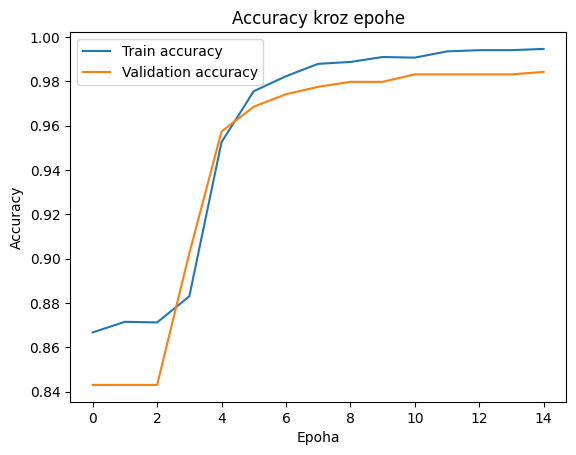

In [224]:
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Accuracy kroz epohe")
plt.xlabel("Epoha")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

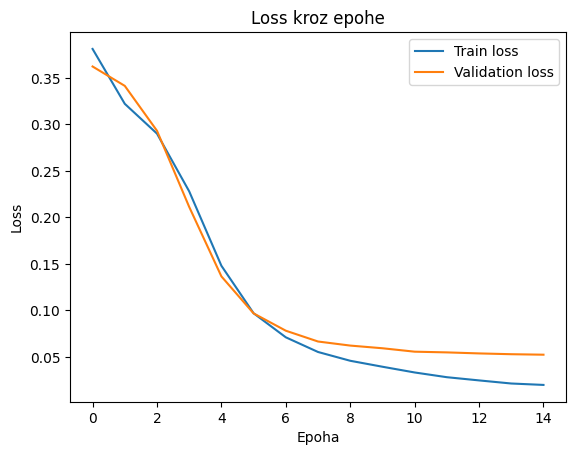

In [225]:
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Loss kroz epohe")
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Evaluacija na test skupu

Test skup nije koristen tokom treniranja modela.

Zato ga koristimo za konacnu provjeru performansi modela.

Na test skupu racunamo loss i accuracy.

In [226]:
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.04451049491763115
Test accuracy: 0.9847533702850342


## Predikcije na test skupu

Model kao izlaz daje vjerovatnocu da je poruka spam.

Posto koristimo sigmoid aktivaciju, izlaz je broj izmedju 0 i 1.

Koristimo prag 0.5:

- ako je vrijednost >= 0.5, poruka je `spam`
- ako je vrijednost < 0.5, poruka je `ham`

In [227]:
y_prob = model.predict(X_test_padded)

y_pred = (y_prob >= 0.5).astype(int).flatten()

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [228]:
for i in range(10):
    print("Poruka:", X_test[i])
    print("Stvarna klasa:", "spam" if y_test[i] == 1 else "ham")
    print("Predikcija:", "spam" if y_pred[i] == 1 else "ham")
    print("Vjerovatnoca spam klase:", round(float(y_prob[i][0]), 4))
    print("-" * 80)

Poruka: No need to buy lunch for me.. I eat maggi mee..
Stvarna klasa: ham
Predikcija: ham
Vjerovatnoca spam klase: 0.0016
--------------------------------------------------------------------------------
Poruka: Ok im not sure what time i finish tomorrow but i wanna spend the evening with you cos that would be vewy vewy lubly! Love me xxx
Stvarna klasa: ham
Predikcija: ham
Vjerovatnoca spam klase: 0.0001
--------------------------------------------------------------------------------
Poruka: Waiting in e car 4 my mum lor. U leh? Reach home already?
Stvarna klasa: ham
Predikcija: ham
Vjerovatnoca spam klase: 0.0004
--------------------------------------------------------------------------------
Poruka: You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327
Stvarna klasa: spam
Predikcija: spam
Vjerovatnoca spam klase: 0.9931
--------------------------------------------------------------------------------
Poruka: If you r @ home then come down within 5 min
Stvarna klasa: ha

Accuracy nije dovoljna metrika zato sto dataset nije balansiran. Ako ima mnogo vise ham poruka, model moze imati visoku accuracy cak i ako slabije prepoznaje spam, zato gledamo i `precision`, `recall` i `F1-score`.

In [229]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["ham", "spam"]
))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.90      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



`Support` znaci koliko je stvarnih primjera bilo u test skupu. Ovo nam govori kao i od ranije da je skup nebalansiran, odnosno da ima mnogo vise `ham` nego `spam` poruka.

`Precision` nam govori koliko cesto je model upravu kada klasificira nesto kao `ham` ili `spam`. Za `ham` nam je 98% a za `spam` nam je 99% upravu prilikom klasifikacije, sto je jako dobro. Model rijetko pogresno oznaci normalnu poruku kao spam.

`Recall` nam govori od svih stvarnih `spam` i `ham` poruka, koliko ih je model pronasao. Za `ham` = 1.0 model je skoro sve `ham` poruke prepoznao kao `ham`. Dok je za `spam` = 0.90 model pronasao oko 90% stvarnih `spam` poruka. To znaci da je oko 10% `spam` poruka propusteno i klasificirano kao `ham`, sto mozemo vidjeti kasnije i na confusion matrici. Prema tome, model je vrlo precizan kada kaze da je nesto spam, ali ne uhvati bas svaki spam.

`F1-score` je metrika koja kombinuje precision i recall u jedan broj. Koristi se kada ne zelimo gledati koliko je model precizan, nego koliko dobro pronalazi stvarne primjerke neke klase.

U sustini `F1-score` pokazuje koliko dobro model balansira izmedju toga da ne pravi lazne spam oznake i toga da ne propusta stvarne spam poruke.

`Accuracy` od priblizno 98.5% pokazuje da model tacno klasifikuje vecinu test poruka, ali moze biti zavaravajuci zato sto ima puno vise `ham` poruka, zato se posebno gleda `spam` recall.

Kod spam detekcije, zelimo da model ima dobar recall za spam klasu, jer zelimo da sto manje spam poruka prodje kao normalna ham poruka.

## Confusion matrix

Confusion matrix prikazuje tacne i pogresne klasifikacije modela.

Za nas problem imamo dvije klase:

- `ham`
- `spam`

Posebno su bitne greske gdje model stvarnu `spam` poruku klasifikuje kao `ham`.

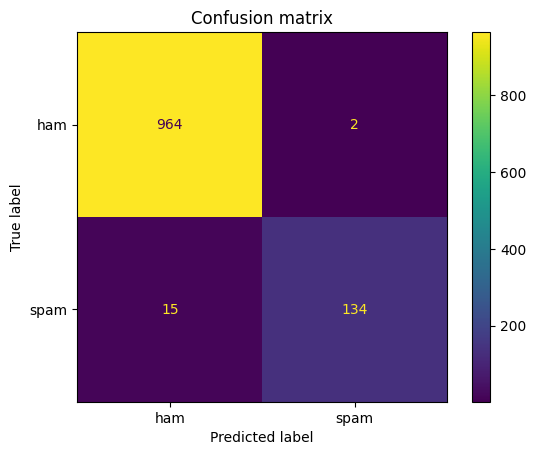

In [230]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

disp.plot()
plt.title("Confusion matrix")
plt.show()

## Funkcija za klasifikaciju nove SMS poruke

Nakon treniranja i evaluacije modela, pravimo funkciju koja prima tekst nove SMS poruke i klasifikuje je kao `spam` ili `ham`.

Nova poruka mora proci kroz isti preprocessing kao i trening podaci:

1. tokenizacija
2. padding
3. predikcija modela

Model vraca vjerovatnocu da je poruka `spam`.

Ako je vjerovatnoca veca ili jednaka 0.5, poruku klasifikujemo kao `spam`.

Ako je vjerovatnoca manja od 0.5, poruku klasifikujemo kao `ham`.

In [231]:
def klasifikuj_sms(tekst):
    sekvenca = tokenizer.texts_to_sequences([tekst])

    padded = pad_sequences(
        sekvenca,
        maxlen=MAX_LENGTH,
        padding=PADDING_TYPE,
        truncating=TRUNC_TYPE
    )

    vjerovatnoca = model.predict(padded, verbose=0)[0][0]

    if vjerovatnoca >= 0.5:
        klasa = "spam"
    else:
        klasa = "ham"

    print("Poruka:", tekst)
    print("Vjerovatnoca spam klase:", round(float(vjerovatnoca), 4))
    print("Predikcija:", klasa)

    return klasa

## Testiranje modela na novim porukama

Sada testiramo model na nekoliko rucno napisanih SMS poruka.

Prva i treca poruka imaju tipicne spam rijeci kao sto su `won`, `free`, `ticket`, `urgent`, `prize` i `call`.

Druga poruka je obicna normalna poruka.

In [232]:
klasifikuj_sms("Congratulations! You won a free ticket. Call now.")

Poruka: Congratulations! You won a free ticket. Call now.
Vjerovatnoca spam klase: 0.8439
Predikcija: spam


'spam'

In [233]:
klasifikuj_sms("Hey, are we still meeting today?")

Poruka: Hey, are we still meeting today?
Vjerovatnoca spam klase: 0.001
Predikcija: ham


'ham'

In [234]:
klasifikuj_sms("URGENT! You have won a prize. Text WIN to 80085 now.")

Poruka: URGENT! You have won a prize. Text WIN to 80085 now.
Vjerovatnoca spam klase: 0.9777
Predikcija: spam


'spam'

In [235]:
klasifikuj_sms("Can you call me when you get home?")

Poruka: Can you call me when you get home?
Vjerovatnoca spam klase: 0.0032
Predikcija: ham


'ham'

In [236]:
# moja_poruka = input("Unesi SMS poruku: ")

moja_poruka = "Hello! Claim your free prize by calling us now!"

klasifikuj_sms(moja_poruka)

Poruka: Hello! Claim your free prize by calling us now!
Vjerovatnoca spam klase: 0.9005
Predikcija: spam


'spam'

## Analiza rezultata i opravdanje izbora koristene metode

Rezultati pokazuju da je model ostvario vrlo dobre performanse. Na test skupu je dobijen test accuracy od priblizno 98.5%, sto znaci da model tacno klasifikuje vecinu SMS poruka. Medjutim, posto dataset nije balansiran i ima mnogo vise `ham` nego `spam` poruka, accuracy sama po sebi nije dovoljna metrika. Zato su koristene i metrike `precision`, `recall` i `F1-score`.

Za klasu `ham`, model ima veoma dobre rezultate, jer skoro sve normalne poruke prepoznaje kao `ham`. Za klasu `spam`, model ima `precision` od `0.99`, sto znaci da kada model oznaci poruku kao spam, skoro uvijek je u pravu. Medjutim, `recall` za spam klasu je `0.90`, sto znaci da model prepoznaje oko 90% stvarnih spam poruka, dok dio spam poruka ipak propusti i klasifikuje kao `ham`.

Zbog toga je glavna metrika koju ima smisla dodatno analizirati upravo `recall` za spam klasu. Kod spam detekcije je vazno da sto manje stvarnih spam poruka prodje kao normalna poruka. Recall bi se mogao poboljsati podesavanjem praga klasifikacije, dodavanjem vise podataka ili koristenjem slozenijih modela.

Izbor metode je opravdan jer je zadatak binarna klasifikacija teksta, a ANN model sa `Embedding` slojem moze automatski uciti korisne karakteristike iz rijeci i poruka. Za razliku od jednostavnijih metoda koje se vise oslanjaju na rucno izdvajanje karakteristika, ovaj pristup omogucava modelu da sam nauci koje rijeci i kombinacije rijeci su vazne za razlikovanje `spam` i `ham` poruka.

## Analiza uticaja promjene praga klasifikacije

Model kao izlaz ne daje direktno klasu spam ili ham, nego vjerovatnocu da je poruka spam.
U osnovnoj verziji koristili smo prag 0.5. To znaci da se poruka klasifikuje kao spam ako je vjerovatnoca veca ili jednaka 0.5.

U nastavku cemo uporediti rezultate za prag 0.5 i prag 0.1. Cilj je provjeriti da li spustanje praga moze poboljsati recall za spam klasu, odnosno smanjiti broj spam poruka koje model pogresno klasifikuje kao ham.

In [237]:
def evaluiraj_prag(prag):
    y_pred_prag = (y_prob >= prag).astype(int).flatten()

    print("-" * 60)
    print(f"REZULTATI ZA PRAG: {prag}")
    print("-" * 60)

    print(classification_report(
        y_test,
        y_pred_prag,
        target_names=["ham", "spam"]
    ))

    cm = confusion_matrix(y_test, y_pred_prag)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["ham", "spam"]
    )

    disp.plot()
    plt.title(f"Confusion matrix za prag {prag}")
    plt.show()

    return y_pred_prag

------------------------------------------------------------
REZULTATI ZA PRAG: 0.5
------------------------------------------------------------
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.90      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



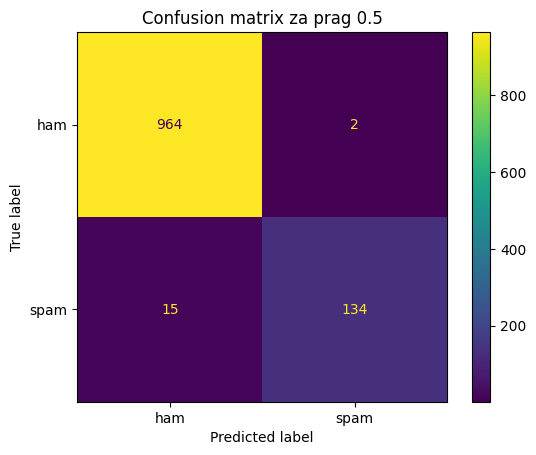

------------------------------------------------------------
REZULTATI ZA PRAG: 0.1
------------------------------------------------------------
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.93      0.95      0.94       149

    accuracy                           0.98      1115
   macro avg       0.96      0.97      0.97      1115
weighted avg       0.98      0.98      0.98      1115



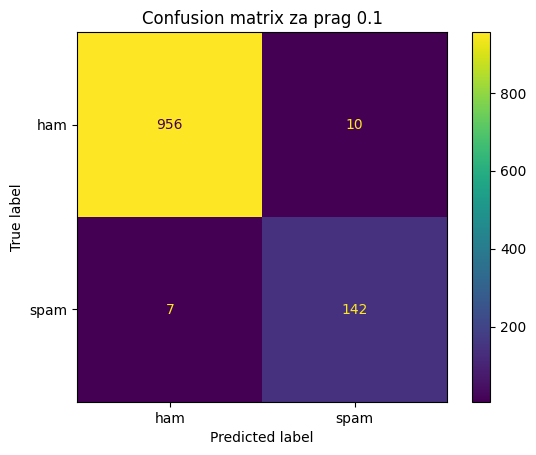

In [238]:
y_pred_05 = evaluiraj_prag(0.5)
y_pred_01 = evaluiraj_prag(0.1)

Spustanjem praga sa `0.5` na `0.1`, model postaje osjetljiviji na `spam` klasu. To znaci da ce i poruke sa manjom vjerovatnocom `spam` klase biti klasifikovane kao `spam`. U nasem slucaju ovo je poboljsalo recall za `spam` klasu sa `0.90` na `0.95`, sto znaci da model propusta manje stvarnih `spam` poruka.

Istovremeno je `precision` za `spam` klasu pao sa `0.99` na `0.93`, sto znaci da se povecao broj normalnih poruka koje su pogresno klasificirane kao `spam`.

Ukupni `F1-score` je osao isti, sto znaci da prag od `0.1` nije nuzno ukupno bolji po svim metrikama, ali je bolji ako nam je prioritet da uhvatimo sto vise stvarnih spam poruka.

ovo pokazuje kompromis izmedju `precision` i `recall`: nizi prag povecava recall ali moze smanjiti precision. U kontekstu spam detekcije, nizi prg moze biti koristan ako nam je vaznije da sto manje spam poruka prodje kao normalna poruka.

Nakon neke retrospekcije, mislim da je bolje ostaviti prag na `0.5` zato sto mislim da ako neke poruke koje se `ham` se klasifikuju kao `spam` moze doci do problema jer je mozda to bila bitna poruka ili je neko stvarno pobjedio nagradnu igru ali je poruka klasifikovana kao spam.

## Zakljucak

U ovom projektu implementiran je ANN model za klasifikaciju SMS poruka kao `spam` ili `ham`.

Koristen je `UCI SMS Spam Collection` dataset.

Tekstualne SMS poruke prvo su pretvorene u numericki oblik pomocu `Tokenizer` klase. Nakon toga su sekvence izjednacene pomocu `pad_sequences`, jer neuronska mreza ocekuje ulaze iste duzine.

Model koristi sljedecu arhitekturu:

- `Embedding` sloj
- `GlobalAveragePooling1D` sloj
- `Dense` sloj
- `Dropout` sloj
- izlazni `Dense` sloj sa `sigmoid` aktivacijom

Posto je zadatak binarna klasifikacija, koristena je `binary_crossentropy` loss funkcija.

Model je evaluiran pomocu:

- accuracy
- precision
- recall
- F1-score
- confusion matrix

Takodjer je napravljena funkcija `klasifikuj_sms`, koja omogucava unos nove SMS poruke i vraca predikciju `spam` ili `ham`.

Na kraju je uradjena i analiza rezultata nakon promjene praga za klasifikaciju sa `0.5` na `0.1`.

Na osnovu dobijenih rezultata moze se zakljuciti da koristeni ANN model dobro rjesava problem SMS spam detekcije. Model postize visoku ukupnu tacnost, veoma dobar precision za spam klasu i solidan recall. Posebno je vazno sto model rijetko pogresno oznacava normalne poruke kao spam, dok ipak uspjesno prepoznaje vecinu stvarnih spam poruka. Zbog toga je odabrani pristup opravdan za ovaj projekat.